## Does proportion contribute to ranking?

**Goal:** Test whether `proportion` the fraction of cells within a perturbation that display the target phenotype influence gene rank.

- A strong negative Spearman ρ (higher proportion → lower/better rank) would indicate that phenotypic penetrance is a meaningful driver of prioritisation.
- A flat or near-zero relationship would suggest that rank is determined by the distance scores alone and `proportion` is a corroborating descriptor without independent predictive power.


In [1]:
suppressPackageStartupMessages({
    library(arrow)
    library(dplyr)
    library(tidyr)
    library(ggplot2)
    library(pheatmap)
    library(viridisLite)
    library(stringr)
    library(stats)
    library(grid)
    library(gridExtra)
})

options(warn = -1)

In [2]:
truncate_palette <- function(palette_fun, min_val = 0.15, max_val = 1.0, n = 256) {
  vals <- seq(min_val, max_val, length.out = n)
  palette_fun(n)[pmax(1, pmin(n, round(vals * n)))]
}

sig_stars <- function(p) {
  if (is.na(p)) return('n.s.')
  if (p < 0.001) return('***')
  if (p < 0.01) return('**')
  if (p < 0.05) return('*')
  'n.s.'
}

In [3]:
# setting result dir
results_dir <- normalizePath('../results/logo_analysis', mustWork = TRUE)

# setting output
output_dir <- normalizePath(file.path(getwd(), 'all-plots', 'rank-and-proportion'), mustWork = FALSE)
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)


In [11]:
# loadding in moa results
moa_results_df <- read_parquet(file.path(results_dir, 'original_mitocheck_logo_analysis_results.parquet')) %>% as_tibble()
shuffled_moa_results_df <- read_parquet(file.path(results_dir, 'shuffled_mitocheck_logo_analysis_results.parquet')) %>% as_tibble()

# rerank perturbation  based on on-Buscar scores(nulls ranked last)
rerank <- function(input_df) {
  input_df %>%
    arrange(target, is.na(on_buscar_scores), on_buscar_scores, perturbation) %>%
    group_by(target) %>%
    mutate(rank = row_number()) %>%
    ungroup()
}

# re rranking based on only on-Buscar scores
moa_results_df <- rerank(moa_results_df)
shuffled_moa_results_df <- rerank(shuffled_moa_results_df)

head(moa_results_df)

target,perturbation,on_buscar_scores,off_buscar_scores,is_reference_distance,proportion,is_associated,rank
<chr>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<lgl>,<int>
ADCCM,RGR,0.4018950,0.1805556,FALSE,0.4305556,TRUE,1
ADCCM,CDK4,0.5187737,0.0000000,FALSE,0.0000000,FALSE,2
ADCCM,ENSG00000175216,0.5224577,0.0000000,FALSE,0.0000000,FALSE,3
ADCCM,CDKL5,0.5306052,0.0000000,FALSE,0.0000000,FALSE,4
ADCCM,LCK,0.5410742,0.0000000,FALSE,0.0000000,FALSE,5
ADCCM,DNCH1,0.5436380,0.0000000,FALSE,0.0000000,FALSE,6


In [5]:
prepare_df <- function(input_df) {
  input_df %>%
    as.data.frame() %>%
    filter(!is.na(on_buscar_scores), !is.na(off_buscar_scores))
}

df <- prepare_df(moa_results_df)
shuf_df <- prepare_df(shuffled_moa_results_df)

profiles <- sort(unique(df$target))
n_profiles <- length(profiles)

In [10]:
run_prop_rank_summary <- function(input_df, label = 'original') {
  prop_df <- input_df %>% select(target, rank, proportion) %>% drop_na()

  cat(sprintf('\n=== %s ===\n', toupper(label)))
  cat(sprintf('Rows used: %d\n', nrow(prop_df)))
  cat(sprintf('Profiles:  %d\n\n', dplyr::n_distinct(prop_df$target)))

  cat(sprintf('%-20s  %7s  %10s\n', 'Profile', '\u03c1', 'p-value'))
  cat(strrep('-', 55), '\n', sep = '')
  for (profile in sort(unique(prop_df$target))) {
    grp <- prop_df %>% filter(target == profile)
    tst <- suppressWarnings(cor.test(grp$proportion, grp$rank, method = 'spearman', exact = FALSE))
    rho_val <- unname(tst$estimate)
    pval <- tst$p.value
    stars <- sig_stars(pval)
    cat(sprintf('%-20s  %+7.3f  %10.2e  %s\n', profile, rho_val, pval, stars))
  }

  tst_all <- suppressWarnings(cor.test(prop_df$proportion, prop_df$rank, method = 'spearman', exact = FALSE))
  rho_all <- unname(tst_all$estimate)
  pval_all <- tst_all$p.value
  cat(sprintf('\nPooled (all profiles):  \u03c1 = %+0.3f  p = %.2e\n', rho_all, pval_all))

  prop_df
}

prop_df <- run_prop_rank_summary(df, 'original')
shuf_prop_df <- run_prop_rank_summary(shuf_df, 'shuffled')


=== ORIGINAL ===
Rows used: 917
Profiles:  16

Profile                    ρ     p-value
-------------------------------------------------------
ADCCM                  -0.068    6.14e-01  n.s.
Anaphase               -0.506    4.28e-05  ***
Apoptosis              -0.667    1.98e-08  ***
Binuclear              -0.765    6.55e-12  ***
Elongated              -0.686    5.51e-09  ***
Folded                 -0.567    2.78e-06  ***
Grape                  -0.332    1.18e-02  *
Hole                   -0.446    4.46e-04  ***
Interphase             -0.768    1.98e-12  ***
Large                  -0.658    3.64e-08  ***
Metaphase              -0.639    2.02e-07  ***
MetaphaseAlignment     -0.168    2.17e-01  n.s.
OutOfFocus             -0.104    4.29e-01  n.s.
Polylobed              -0.828    1.09e-15  ***
Prometaphase           -0.540    1.02e-05  ***
SmallIrregular         -0.568    3.32e-06  ***

Pooled (all profiles):  ρ = -0.518  p = 3.42e-64

=== SHUFFLED ===
Rows used: 917
Profiles:  16

Prof

In [7]:
fit_and_report <- function(prop_df, label = 'original') {
  cat(sprintf('\n=== OLS: %s (rank ~ proportion) ===\n', toupper(label)))
  model_prop <- lm(rank ~ proportion, data = prop_df)
  print(summary(model_prop))
  invisible(model_prop)
}

model_prop <- fit_and_report(prop_df, 'original')
model_prop_shuf <- fit_and_report(shuf_prop_df, 'shuffled')


=== OLS: ORIGINAL (rank ~ proportion) ===

Call:
lm(formula = rank ~ proportion, data = prop_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-30.466 -12.975  -0.466  12.534  47.312 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  31.4657     0.5392   58.35   <2e-16 ***
proportion  -35.7779     2.8762  -12.44   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 15.35 on 915 degrees of freedom
Multiple R-squared:  0.1446,	Adjusted R-squared:  0.1437 
F-statistic: 154.7 on 1 and 915 DF,  p-value: < 2.2e-16


=== OLS: SHUFFLED (rank ~ proportion) ===

Call:
lm(formula = rank ~ proportion, data = prop_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-28.4506 -14.4506  -0.1579  14.0473  30.5494 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  29.4506     0.5824  50.565   <2e-16 ***
proportion   -4.2823     3.1067  -1.378    0.168    
---
Signif. codes:

Saved -> /home/erikserrano/Projects/buscar/notebooks/2.mitocheck-analysis/plots/all-plots/rank-and-proportion/proportion_vs_rank_all_profiles.png
Saved -> /home/erikserrano/Projects/buscar/notebooks/2.mitocheck-analysis/plots/all-plots/rank-and-proportion/shuffled_proportion_vs_rank_all_profiles.png


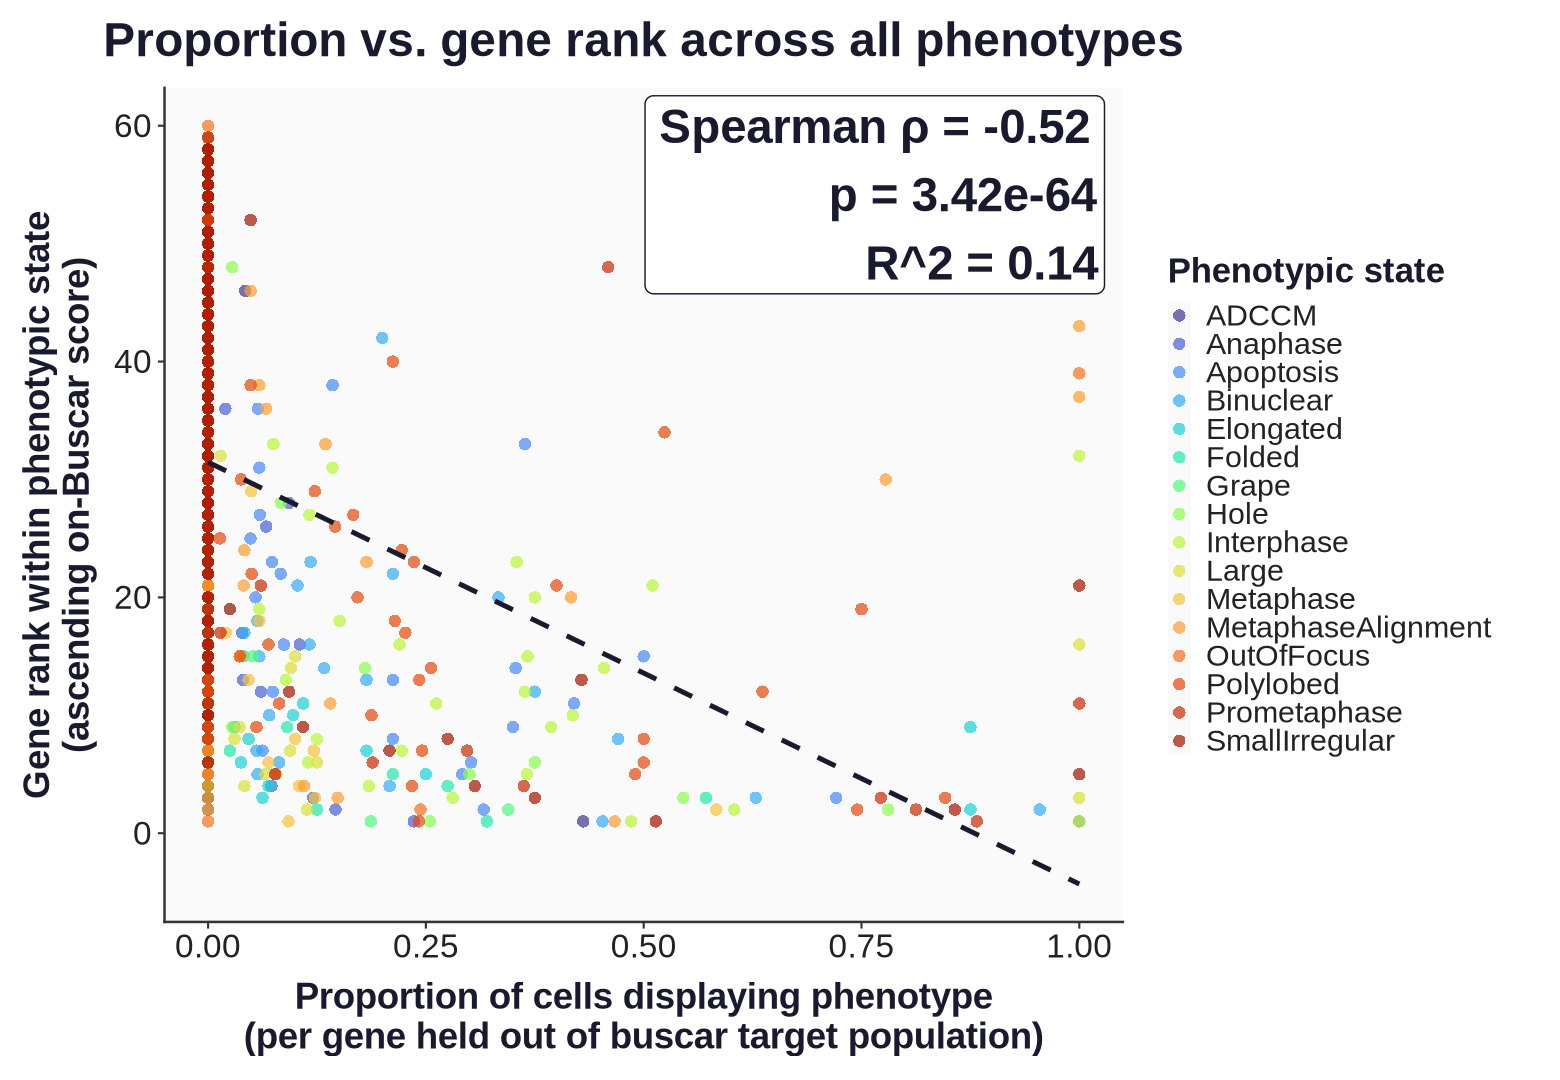

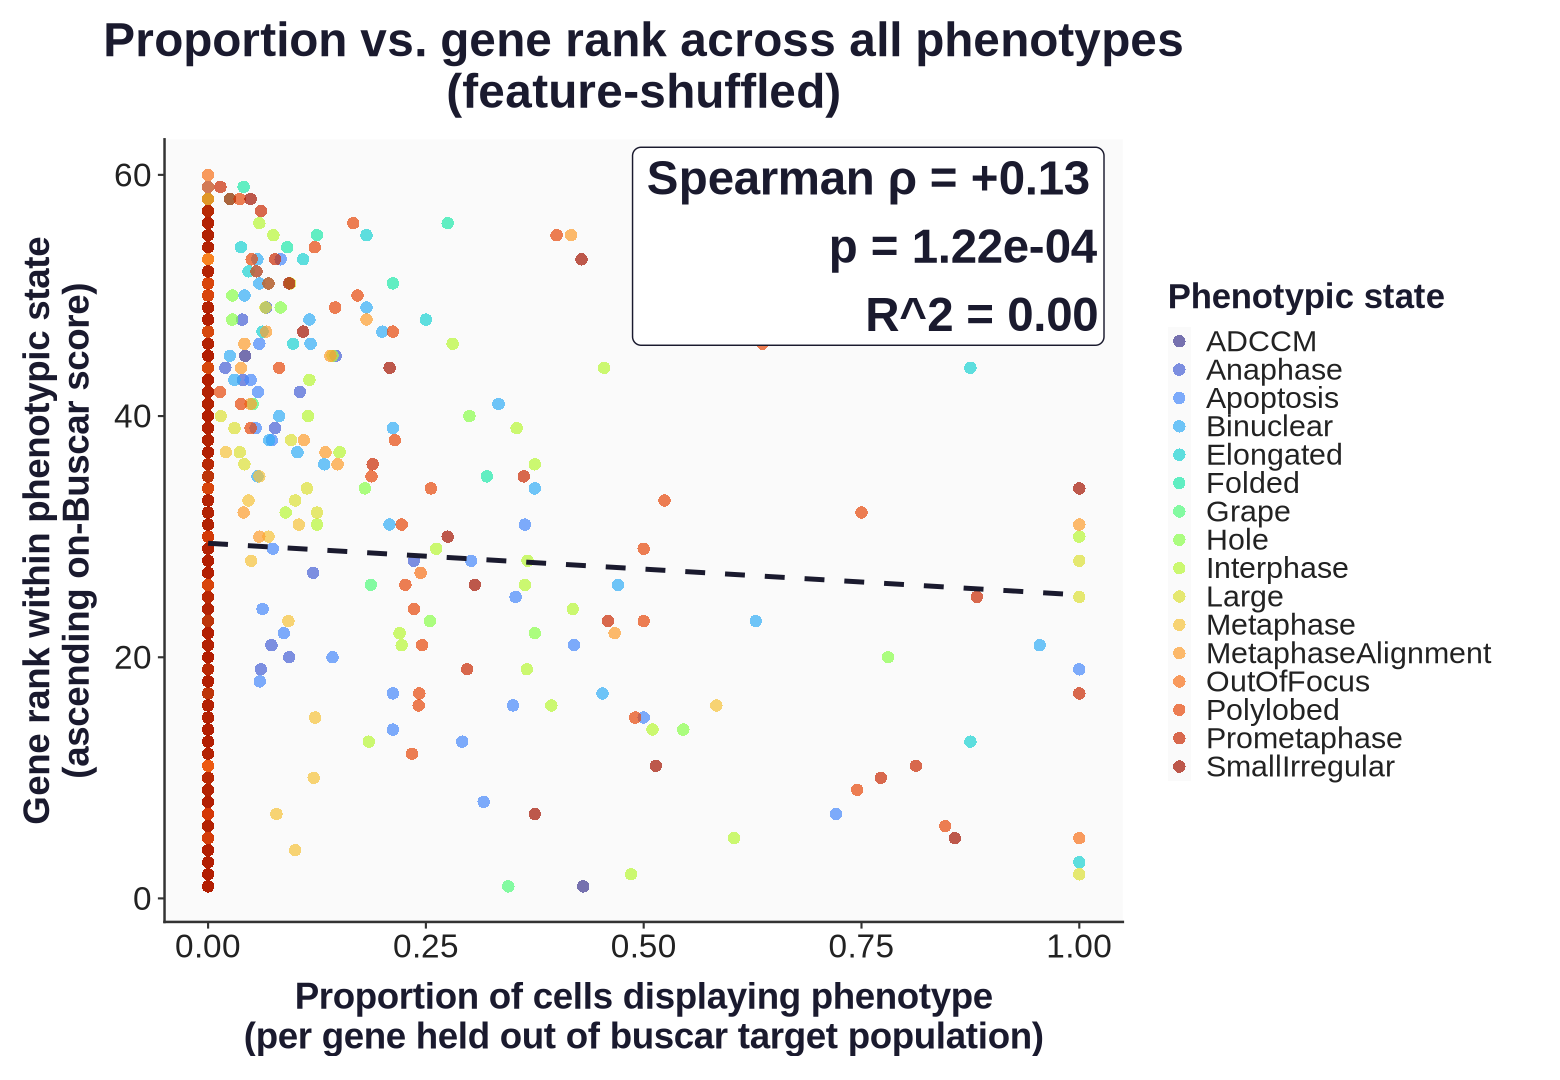

In [8]:
options(repr.plot.width = 13, repr.plot.height = 9)

plot_prop_vs_rank <- function(prop_df, title_txt, out_name) {
  fit <- lm(rank ~ proportion, data = prop_df)
  r_val <- suppressWarnings(cor(prop_df$proportion, prop_df$rank, use = 'complete.obs', method = 'pearson'))
  r2 <- r_val^2

  tst_all <- suppressWarnings(cor.test(prop_df$proportion, prop_df$rank, method = 'spearman', exact = FALSE))
  rho_all <- unname(tst_all$estimate)
  pval_all <- tst_all$p.value

  p_all <- ggplot(prop_df, aes(x = proportion, y = rank, color = target)) +
    geom_point(alpha = 0.7, size = 3.5, stroke = 0) +
    geom_smooth(
      method = 'lm', formula = y ~ x, se = FALSE,
      color = '#1a1a2e', linetype = 'dashed', linewidth = 1.4,
      inherit.aes = FALSE, aes(x = proportion, y = rank)
    ) +
    annotate(
      'label',
      x = Inf, y = Inf, hjust = 1.04, vjust = 1.04,
      label = sprintf('Spearman \u03c1 = %+.2f\np = %.2e\nR^2 = %.2f', rho_all, pval_all, r2),
      size = 10, label.size = 0.8, fill = 'white', color = '#1a1a2e', fontface = 'bold'
    ) +
    scale_color_viridis_d(option = 'turbo', begin = 0.05, end = 0.95) +
    labs(
      x = 'Proportion of cells displaying phenotype\n(per gene held out of buscar target population)',
      y = 'Gene rank within phenotypic state\n(ascending on-Buscar score)',
      color = 'Phenotypic state',
      title = title_txt
    ) +
    theme_classic(base_size = 18) +
    theme(
      plot.title = element_text(face = 'bold', size = 28.6, color = '#1a1a2e', hjust = 0.5,
      margin = margin(b = 12)),
      axis.title.x = element_text(face = 'bold', size = 22, color = '#1a1a2e', margin = margin(t = 10)),
      axis.title.y = element_text(face = 'bold', size = 22, color = '#1a1a2e', margin = margin(r = 10)),
      axis.text.x = element_text(size = 20, color = '#222222'),
      axis.text.y = element_text(size = 20, color = '#222222'),
      axis.line = element_line(linewidth = 0.7, color = '#333333'),
      axis.ticks = element_line(linewidth = 0.6, color = '#333333'),
      axis.ticks.length = unit(4, 'pt'),
      legend.title = element_text(face = 'bold', size = 20.8, color = '#1a1a2e'),
      legend.text = element_text(size = 18.2, color = '#222222'),
      legend.key.size = unit(14, 'pt'),
      legend.position = 'right',
      legend.background = element_rect(fill = 'white', color = NA),
      panel.background = element_rect(fill = '#fafafa', color = NA),
      plot.background = element_rect(fill = 'white', color = NA),
      plot.margin = margin(14, 20, 14, 14)
    )

  out_path <- file.path(output_dir, out_name)
  ggsave(out_path, p_all, width = 13, height = 9, dpi = 300, bg = 'white')
  cat(sprintf('Saved -> %s\n', out_path))
  print(p_all)
}

plot_prop_vs_rank(
  prop_df,
  'Proportion vs. gene rank across all phenotypes',
  'proportion_vs_rank_all_profiles.png'
)

plot_prop_vs_rank(
  shuf_prop_df,
  'Proportion vs. gene rank across all phenotypes\n(feature-shuffled)',
  'shuffled_proportion_vs_rank_all_profiles.png'
)

In [17]:
tst_all <- cor.test(shuf_prop_df$proportion, shuf_prop_df$rank, method = 'spearman', exact = FALSE)
tst_all



	Spearman's rank correlation rho

data:  shuf_prop_df$proportion and shuf_prop_df$rank
S = 112257191, p-value = 0.0001224
alternative hypothesis: true rho is not equal to 0
sample estimates:
    rho 
0.12651 


Saved -> /home/erikserrano/Projects/buscar/notebooks/2.mitocheck-analysis/plots/all-plots/rank-and-proportion/proportion_vs_rank_faceted_by_phenotype.png
Saved -> /home/erikserrano/Projects/buscar/notebooks/2.mitocheck-analysis/plots/all-plots/rank-and-proportion/shuffled_proportion_vs_rank_faceted_by_phenotype.png


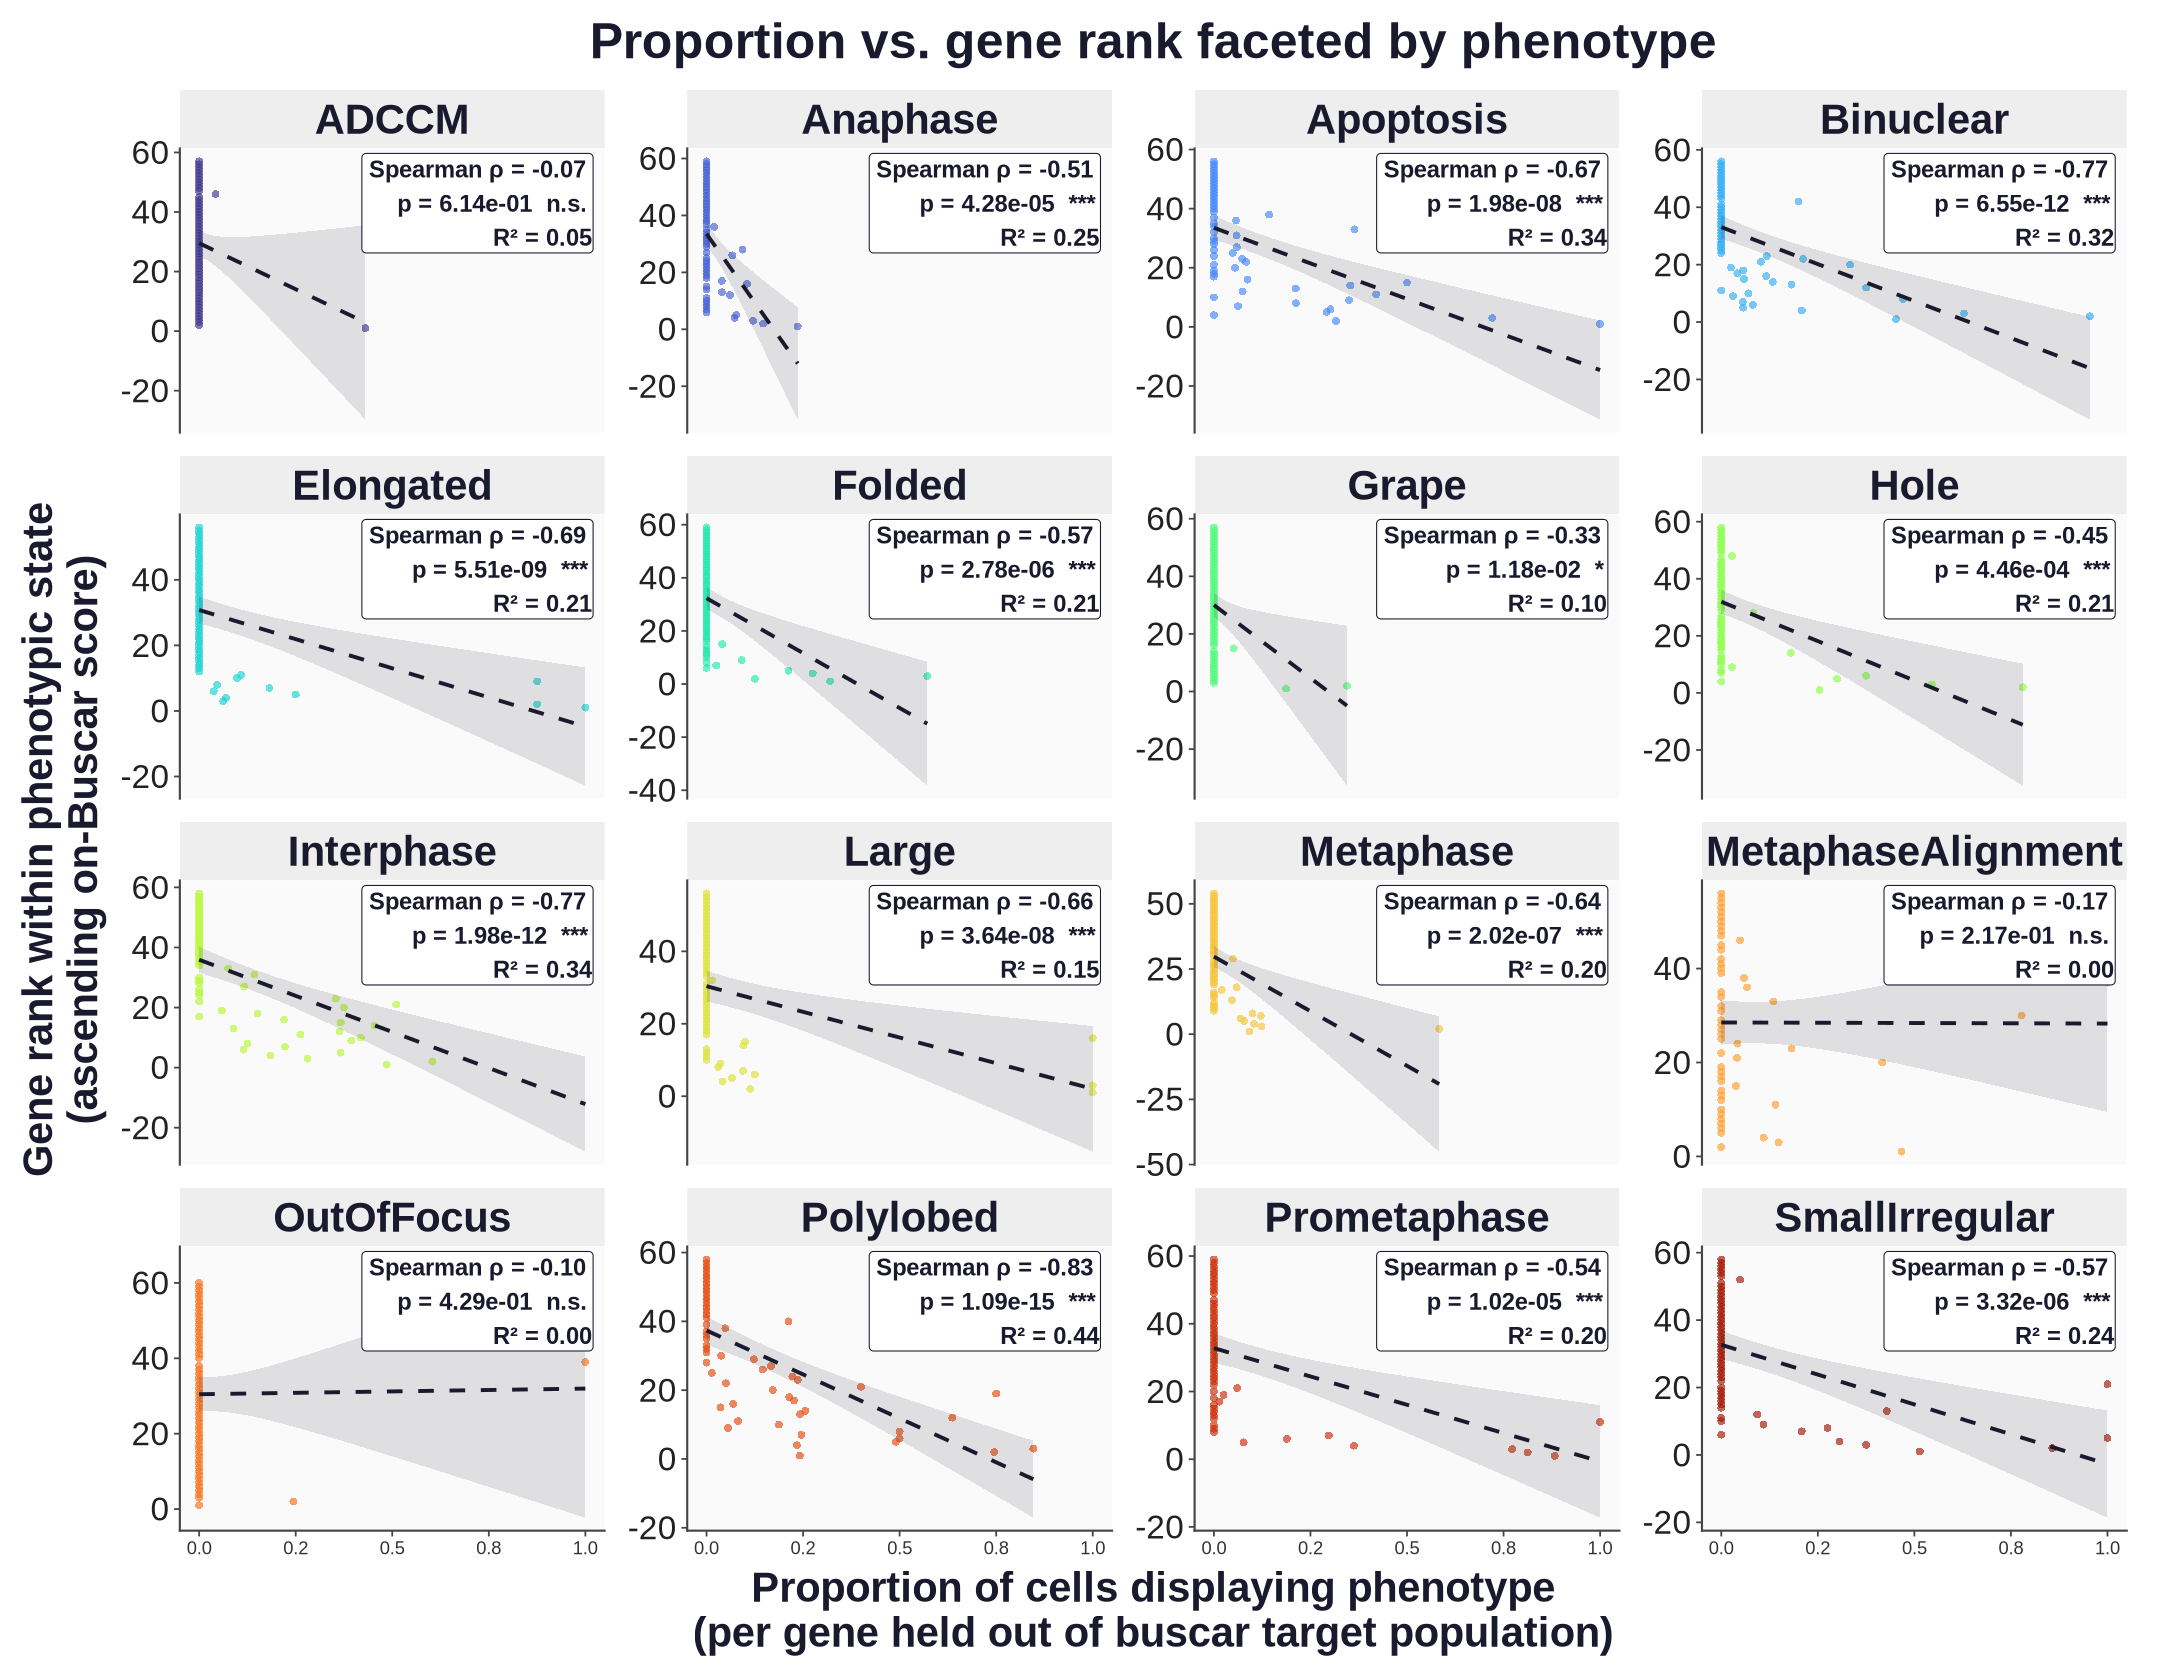

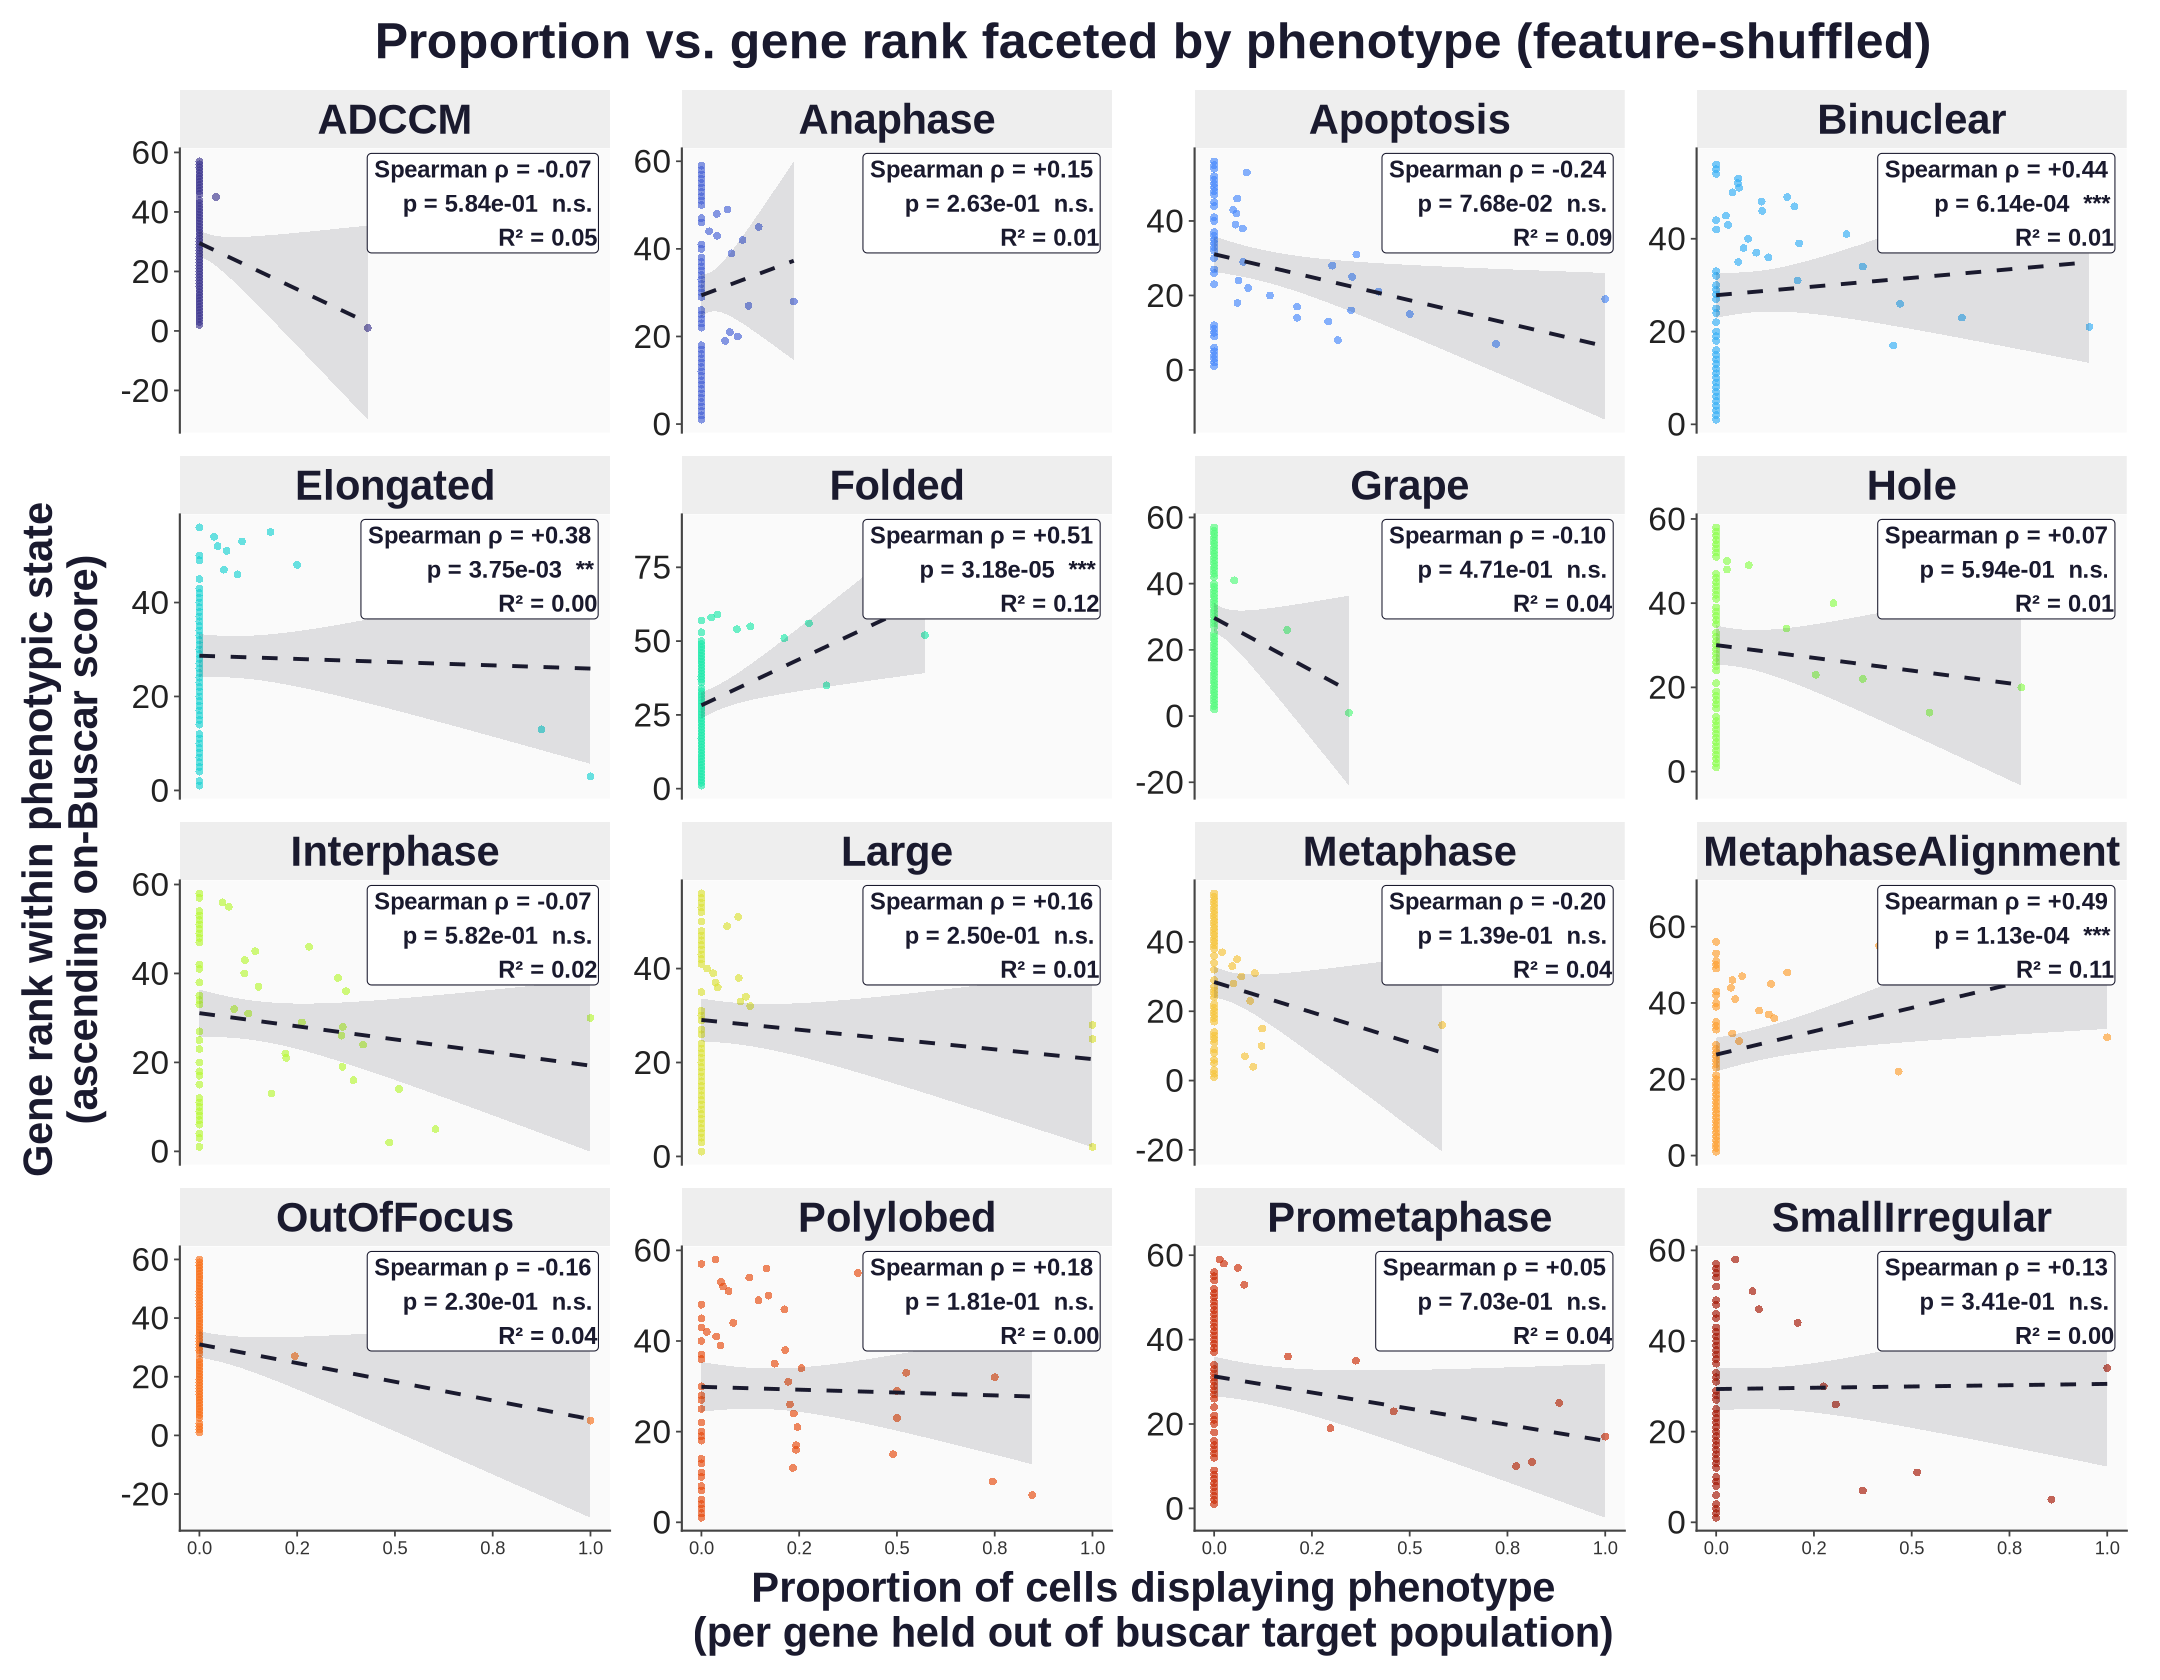

In [9]:
options(repr.plot.width = 18, repr.plot.height = 14)

plot_prop_vs_rank_faceted <- function(prop_df, title_txt, out_name) {
  # compute per-phenotype spearman stats and R^2 for annotation labels
  annot_df <- prop_df %>%
    group_by(target) %>%
    summarise(
      rho  = suppressWarnings(cor.test(proportion, rank, method = 'spearman', exact = FALSE)$estimate),
      pval = suppressWarnings(cor.test(proportion, rank, method = 'spearman', exact = FALSE)$p.value),
      r2   = cor(proportion, rank, use = 'complete.obs', method = 'pearson')^2,
      .groups = 'drop'
    ) %>%
    mutate(
      stars = sapply(pval, sig_stars),
      label = sprintf('Spearman \u03c1 = %+.2f\np = %.2e  %s\nR\u00b2 = %.2f', rho, pval, stars, r2),
      x_pos = Inf,
      y_pos = Inf
    )

  p_facet <- ggplot(prop_df, aes(x = proportion, y = rank)) +
    geom_point(aes(color = target), alpha = 0.65, size = 2.2, stroke = 0) +
    geom_smooth(
      method = 'lm', formula = y ~ x, se = TRUE,
      color = '#1a1a2e', fill = '#1a1a2e', alpha = 0.12,
      linetype = 'dashed', linewidth = 1.1
    ) +
    geom_label(
      data = annot_df,
      aes(x = x_pos, y = y_pos, label = label),
      hjust = 1.05, vjust = 1.05,
      size = 5.0, label.size = 0.3,
      fill = 'white', color = '#1a1a2e', fontface = 'bold',
      inherit.aes = FALSE
    ) +
    facet_wrap(~ target, scales = 'free_y', ncol = 4) +
    scale_color_viridis_d(option = 'turbo', begin = 0.05, end = 0.95) +
    scale_x_continuous(labels = scales::label_number(accuracy = 0.1)) +
    labs(
      x = 'Proportion of cells displaying phenotype\n(per gene held out of buscar target population)',
      y = 'Gene rank within phenotypic state\n(ascending on-Buscar score)',
      title = title_txt
    ) +
    theme_classic(base_size = 14) +
    theme(
      plot.title       = element_text(face = 'bold', size = 30, color = '#1a1a2e',
                                      hjust = 0.5, margin = margin(b = 12)),
      strip.text       = element_text(face = 'bold', size = 25, color = '#1a1a2e'),
      strip.background = element_rect(fill = '#eeeeee', color = NA),
      axis.title.x     = element_text(face = 'bold', size = 25, color = '#1a1a2e',
                                      margin = margin(t = 8)),
      axis.title.y     = element_text(face = 'bold', size = 25, color = '#1a1a2e',
                                      margin = margin(r = 8)),
      axis.text        = element_text(size = 11, color = '#333333'),
      axis.line        = element_line(linewidth = 0.6, color = '#444444'),
      axis.ticks       = element_line(linewidth = 0.5, color = '#444444'),
      axis.text.y = element_text(size = 20, color = '#222222'),
      legend.position  = 'none',
      panel.background = element_rect(fill = '#fafafa', color = NA),
      plot.background  = element_rect(fill = 'white', color = NA),
      panel.spacing    = unit(14, 'pt'),
      plot.margin      = margin(14, 20, 14, 14)
    )

  out_path <- file.path(output_dir, out_name)
  ggsave(out_path, p_facet, width = 18, height = 14, dpi = 300, bg = 'white')
  cat(sprintf('Saved -> %s\n', out_path))
  print(p_facet)
}

plot_prop_vs_rank_faceted(
  prop_df,
  'Proportion vs. gene rank faceted by phenotype',
  'proportion_vs_rank_faceted_by_phenotype.png'
)

plot_prop_vs_rank_faceted(
  shuf_prop_df,
  'Proportion vs. gene rank faceted by phenotype (feature-shuffled)',
  'shuffled_proportion_vs_rank_faceted_by_phenotype.png'
)